In [2]:
'''Import modules and load data'''
import sqlite3
# import cudf
import pandas as pd
from tqdm import tqdm
# import gc
# from numba import cuda
import os
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import optuna
import numpy as np
from sklearn.metrics import mean_squared_error
from scipy.special import logit, expit
import lightgbm as lgb
import joblib
import dask.dataframe as dd
from sqlalchemy import create_engine, text
import openmeteo_requests
import requests_cache
from retry_requests import retry




# os.chdir('/home/rapids/Capstone')

# From the sqlite data file import into a cudf dataframe the data from the years 2022 and 2023, from months 1 to 5 and from station_id 1 to 496
# def load_data_in_chunks(chunk_size=10000):
#     # Connect to the sqlite database
#     conn = sqlite3.connect('data.sqlite')
#     # Write query
#     query = '''SELECT * FROM data_table WHERE year IN (2022, 2023) AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
#     # Create a generator for chunks
#     for chunk in pd.read_sql_query(query, conn, chunksize=chunk_size):
#         # Convert the pandas chunk to a cudf dataframe
#         yield cudf.DataFrame.from_pandas(chunk)
#     # Close the connection
#     conn.close()

# # Load the data in chunks and process
# df_list = []
# for chunk in tqdm(load_data_in_chunks(chunk_size=10000)):
#     df_list.append(chunk)

# # Concatenate all chunks into a single cudf dataframe
# df = cudf.concat(df_list, ignore_index=True)

# # Print the first 5 rows
# df.head(10)

In [2]:
# # Prepare a second dataframe with the year 2024

# def test_data_in_chunks():
#     # Connect to the sqlite database
#     conn = sqlite3.connect('data.sqlite')
#     # Write query
#     query = '''SELECT * FROM data_table WHERE year = 2024 AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
#     # Create a generator for chunks
#     for chunk in pd.read_sql_query(query, conn, chunksize=10000):
#         # convert the pandas chunk to a cudf dataframe
#         yield cudf.DataFrame.from_pandas(chunk)
#     # Close the connection
#     conn.close()

# # Load the data in chunks and process
# df_list = []
# for chunk in tqdm(test_data_in_chunks()):
#     df_list.append(chunk)

# # Concatenate all chunks into a single cudf dataframe
# test_df = cudf.concat(df_list, ignore_index=True)

# # Print the first 5 rows
# test_df.head(10)

10it [00:00, 44.98it/s]

514it [00:57,  8.94it/s]


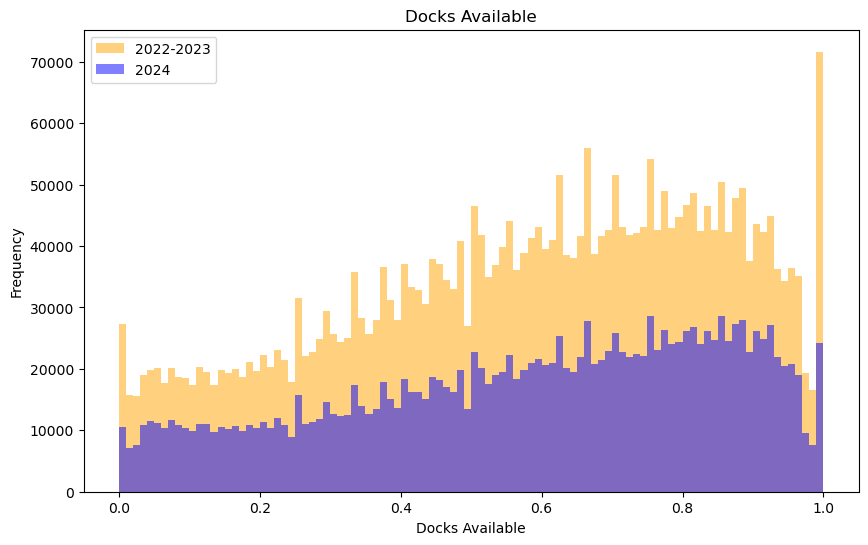

16323

In [3]:
# From the sqlite database, import the docks_available column from the data_table for the years 2022-2024, from months 1 to 5 and from station_id 1 to 496
def target_data_retrieve():
    # Make the connection to the database
    conn = sqlite3.connect('data.sqlite')
    # Write the query
    query = '''SELECT docks_available, year FROM data_table WHERE year IN (2022, 2023, 2024) AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
    # Read the query into a pandas dataframe
    for chunk in pd.read_sql_query(query, conn, chunksize=10000):
        yield pd.DataFrame(chunk)
    # Close the connection
    conn.close()
docks_available = pd.DataFrame()
# Load the data
for chunk in tqdm(target_data_retrieve()):
    docks_available = pd.concat([docks_available, chunk])

# Plot a histogram for the years 2022 and 2023, and another for the year 2024

plt.figure(figsize=(10, 6))
plt.hist(docks_available[docks_available['year'] != 2024]['docks_available'], bins=100, alpha=0.5, label='2022-2023', color='orange')
plt.hist(docks_available[docks_available['year'] == 2024]['docks_available'], bins=100, alpha=0.5, label='2024', color='blue')
plt.legend()
plt.title('Docks Available')
plt.xlabel('Docks Available')
plt.ylabel('Frequency')
plt.show()

# Release memory
del docks_available
gc.collect()

338it [00:30, 11.05it/s]


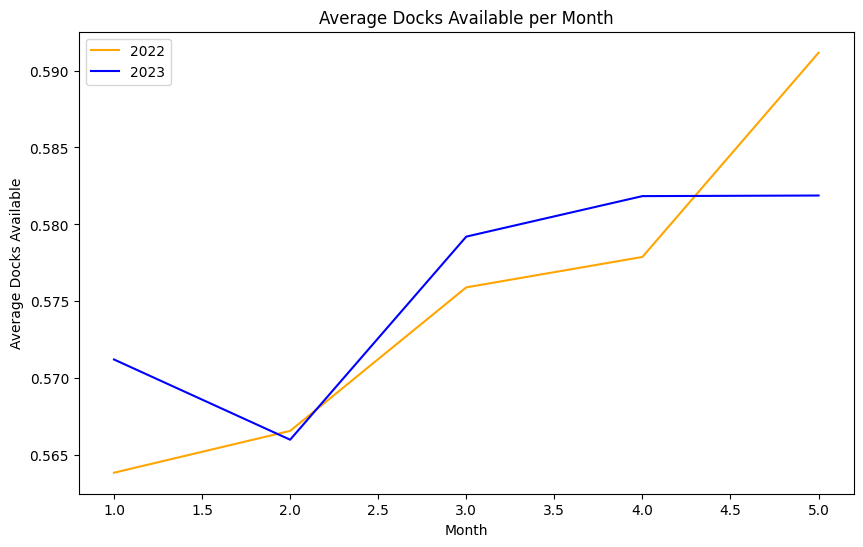

In [40]:
# Import docks_available and timestamp columns from the data_table for the years 2022-2023, from months 1 to 5 and from station_id 1 to 496

def feature_data_retrieve():
    # Make the connection to the database
    conn = sqlite3.connect('data.sqlite')
    # Write the query
    query = '''SELECT docks_available, timestamp, year, month FROM data_table WHERE year IN (2022, 2023) AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
    # Read the query into a pandas dataframe
    for chunk in pd.read_sql_query(query, conn, chunksize=10000):
        yield pd.DataFrame(chunk)
    # Close the connection
    conn.close()

feature_data = pd.DataFrame()

# Load the data
for chunk in tqdm(feature_data_retrieve()):
    feature_data = pd.concat([feature_data, chunk])

# Obtain the average docks_available per month for the years 2022 and 2023
feature_data['timestamp'] = pd.to_datetime(feature_data['timestamp'])
feature_data['month'] = feature_data['timestamp'].dt.month
feature_data['year'] = feature_data['timestamp'].dt.year

# Group by year and month
feature_data = feature_data.groupby(['year', 'month']).agg({'docks_available': 'mean'}).reset_index()

# Plot the average docks_available per month
plt.figure(figsize=(10, 6))
plt.plot(feature_data[feature_data['year'] == 2022]['month'], feature_data[feature_data['year'] == 2022]['docks_available'], label='2022', color='orange')
plt.plot(feature_data[feature_data['year'] == 2023]['month'], feature_data[feature_data['year'] == 2023]['docks_available'], label='2023', color='blue')
plt.legend()
plt.title('Average Docks Available per Month')
plt.xlabel('Month')
plt.ylabel('Average Docks Available')
plt.show()  


# Release memory
del feature_data
# gc.collect()
# cuda.current_context().deallocations.clear()
# cuda.current_context().reset()

177it [00:15, 11.56it/s]


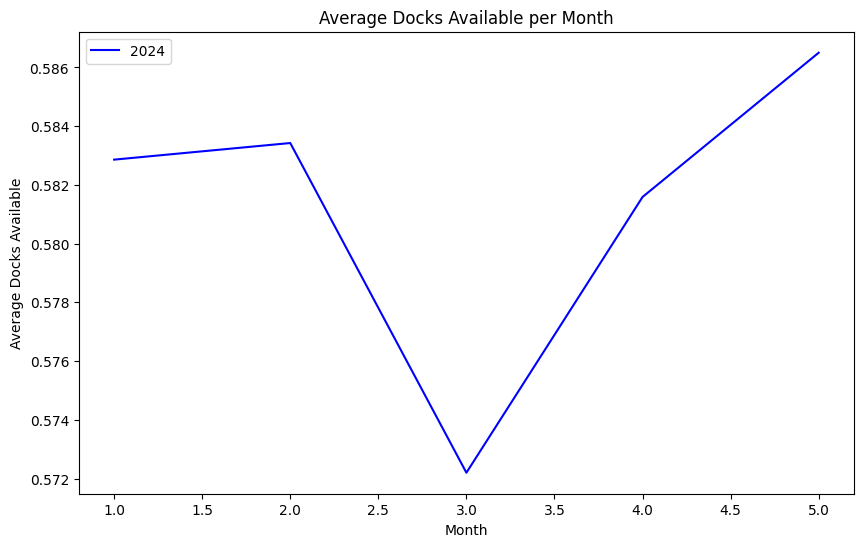

NameError: name 'gc' is not defined

In [50]:
# Repeat the operation for 2024

def feature_data_retrieve():
    # Make the connection to the database
    conn = sqlite3.connect('data.sqlite')
    # Write the query
    query = '''SELECT docks_available, timestamp, year, month FROM data_table WHERE year = 2024 AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
    # Read the query into a pandas dataframe
    for chunk in pd.read_sql_query(query, conn, chunksize=10000):
        yield pd.DataFrame(chunk)
    # Close the connection
    conn.close()

feature_data = pd.DataFrame()

# Load the data
for chunk in tqdm(feature_data_retrieve()):
    feature_data = pd.concat([feature_data, chunk])

# Obtain the average docks_available per month for the year 2024
feature_data['timestamp'] = pd.to_datetime(feature_data['timestamp'])
feature_data['month'] = feature_data['timestamp'].dt.month
feature_data['year'] = feature_data['timestamp'].dt.year

# Group by year and month
feature_data = feature_data.groupby(['year', 'month']).agg({'docks_available': 'mean'}).reset_index()

# Plot the average docks_available per month
plt.figure(figsize=(10, 6))
plt.plot(feature_data[feature_data['year'] == 2024]['month'], feature_data[feature_data['year'] == 2024]['docks_available'], label='2024', color='blue')
plt.legend()
plt.title('Average Docks Available per Month')
plt.xlabel('Month')
plt.ylabel('Average Docks Available')
plt.show()

# Release memory
del feature_data
gc.collect()
cuda.current_context().deallocations.clear()
cuda.current_context().reset()

0it [00:00, ?it/s]

338it [01:22,  4.11it/s]


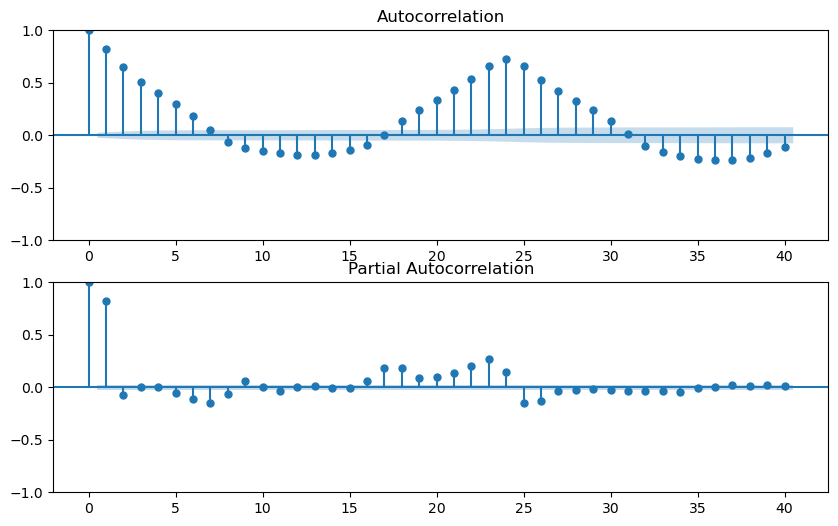

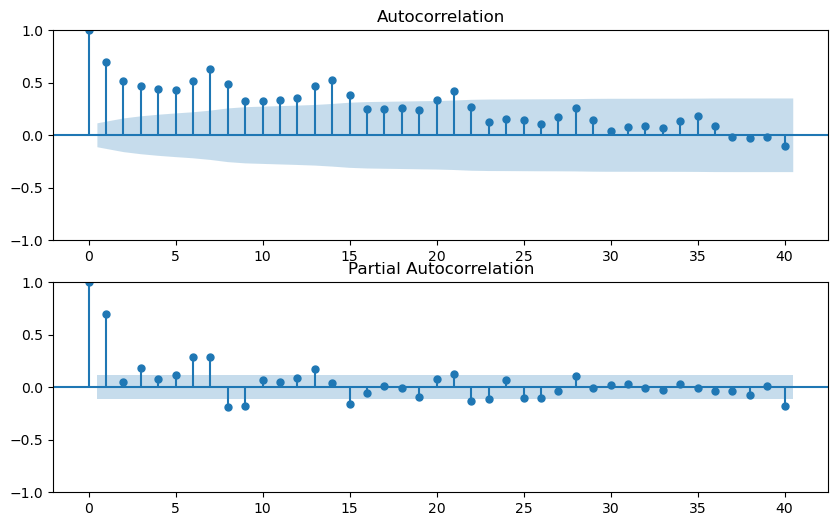

<Figure size 640x480 with 0 Axes>

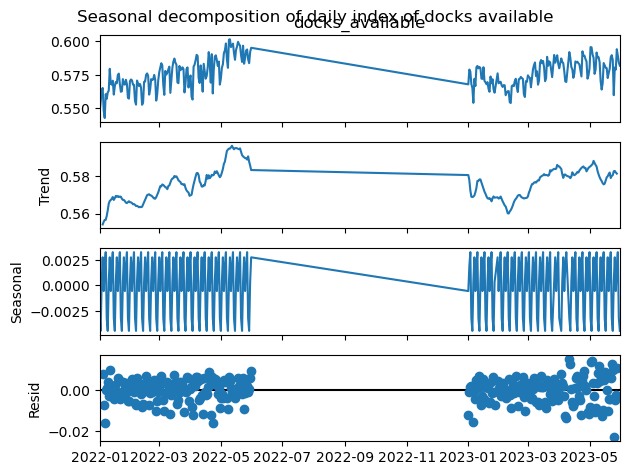

<Figure size 640x480 with 0 Axes>

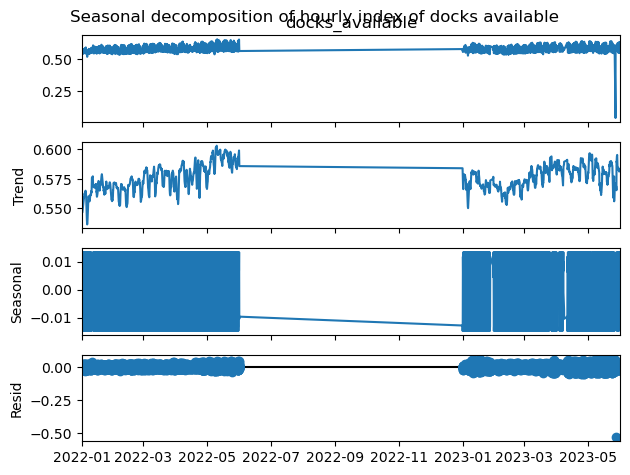

In [ ]:
# Import the following columns from the database
required_columns = ['station_id', 'docks_available', 'timestamp', 'year', 'month', 'day', 'hour', 'temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'wind_speed_10m', 'sunshine_duration']

# Now import from the data_table for the years 2022-2023, from months 1 to 5 and from station_id 1 to 496
def feature_data_retrieve():
    # Make the connection to the database
    conn = sqlite3.connect('data.sqlite')
    # Write the query
    query = '''SELECT station_id, docks_available, timestamp, year, month, day, hour, temperature_2m, apparent_temperature, relative_humidity_2m, wind_speed_10m, sunshine_duration FROM data_table WHERE year IN (2022, 2023) AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
    # Read the query into a pandas dataframe
    for chunk in pd.read_sql_query(query, conn, chunksize=10000):
        yield pd.DataFrame(chunk)
    # Close the connection
    conn.close()

feature_data = pd.DataFrame()

# Load the data
for chunk in tqdm(feature_data_retrieve()):
    feature_data = pd.concat([feature_data, chunk])


# Convert the timestamp column to datetime
feature_data['timestamp'] = pd.to_datetime(feature_data['timestamp'])

# Make timestamp the index
feature_data.set_index('timestamp', inplace=True)

# Resample two dataframes, to hourly and daily
target_data_hourly = feature_data['docks_available'].resample('h').mean()
target_data_daily = feature_data['docks_available'].resample('D').mean()
# Function to plot the ACF and PACF
def plot_acf_pacf(data, lags=40):
    fig, ax = plt.subplots(2, 1, figsize=(10, 6))
    plot_acf(data.dropna(), lags=lags, ax=ax[0])
    plot_pacf(data.dropna(), lags=lags, ax=ax[1], method='ywm')
    plt.show()

# Plot the ACF and PACF for the hourly data
plot_acf_pacf(target_data_hourly)
plot_acf_pacf(target_data_daily)

'''Seasonal Decomposition'''
# Daily decomposition (period=7 for weekly seasonality)
daily_clean = target_data_daily.dropna()
# Remove months that are not between January and May
daily_clean = daily_clean[(daily_clean.index.month >= 1) & (daily_clean.index.month <= 5)]
decomp_daily = seasonal_decompose(daily_clean, model='additive', period=7)

plt.figure()
decomp_daily.plot()
plt.suptitle('Seasonal decomposition of daily index of docks available')
plt.show()

# Hourly decomposition (period=24 for daily seasonality)
hourly_clean = target_data_hourly.dropna()
# Remove months that are not between 1 and 5
hourly_clean = hourly_clean[(hourly_clean.index.month >= 1) & (hourly_clean.index.month <= 5)]
decomp_hourly = seasonal_decompose(hourly_clean, model='additive', period=24)

plt.figure()
decomp_hourly.plot()
plt.suptitle('Seasonal decomposition of hourly index of docks available')
plt.show()

# Release memory
del feature_data
del target_data_hourly
del target_data_daily
gc.collect()
cuda.current_context().deallocations.clear()
cuda.current_context().reset()




In [23]:
# Import the relevant data from the database
def feature_data_retrieve():
    # Make the connection to the database
    conn = sqlite3.connect('data.sqlite')
    # Write the query
    query = '''SELECT station_id, docks_available, timestamp, year, month, day, hour, temperature_2m, apparent_temperature, relative_humidity_2m, wind_speed_10m, sunshine_duration, rain FROM data_table WHERE year IN (2022, 2024) AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
    # Read the query into a pandas dataframe
    for chunk in pd.read_sql_query(query, conn, chunksize=10000):
        yield pd.DataFrame(chunk)
    # Close the connection
    conn.close()

feature_data = pd.DataFrame()

# Load the data
for chunk in tqdm(feature_data_retrieve()):
    feature_data = pd.concat([feature_data, chunk])

# Convert the timestamp column to datetime
feature_data['timestamp'] = pd.to_datetime(feature_data['timestamp'])

# Make timestamp the index
feature_data.set_index('timestamp', inplace=True)

# Sort the feature data by station_id and then station_id by timestamp
feature_data.sort_values(by=['station_id', 'timestamp'], inplace=True)

# Engineer features, four columns which will have docks available shifted by 1, 2, 3, and 4 hours before the current timestamp. They are called ctx-1, ctx-2, ctx-3, and ctx-4
feature_data['ctx-1'] = feature_data.groupby('station_id')['docks_available'].shift(1)
feature_data['ctx-2'] = feature_data.groupby('station_id')['docks_available'].shift(2)
feature_data['ctx-3'] = feature_data.groupby('station_id')['docks_available'].shift(3)
feature_data['ctx-4'] = feature_data.groupby('station_id')['docks_available'].shift(4)


# Drop rows with missing values
feature_data.dropna(inplace=True)

# Drop columns that are not needed
feature_data.drop(columns=['relative_humidity_2m'], inplace=True)
feature_data.drop(columns=['temperature_2m'], inplace=True)

# Convert the timestamp into a column again and reset the index
feature_data.reset_index(inplace=True)



# Normalize the columns apparent_temperature, wind_speed_10m, sunshine_duration, and rain
feature_data['apparent_temperature'] = (feature_data['apparent_temperature'] - feature_data['apparent_temperature'].min()) / (feature_data['apparent_temperature'].max() - feature_data['apparent_temperature'].min())
feature_data['wind_speed_10m'] = (feature_data['wind_speed_10m'] - feature_data['wind_speed_10m'].min()) / (feature_data['wind_speed_10m'].max() - feature_data['wind_speed_10m'].min())
feature_data['sunshine_duration'] = (feature_data['sunshine_duration'] - feature_data['sunshine_duration'].min()) / (feature_data['sunshine_duration'].max() - feature_data['sunshine_duration'].min())
feature_data['rain'] = (feature_data['rain'] - feature_data['rain'].min()) / (feature_data['rain'].max() - feature_data['rain'].min())

# display(feature_data.head(10))

train_set = feature_data[feature_data['year'] < 2024]
test_set = feature_data[feature_data['year'] == 2024]

# # Feature list
FEATURES = ['station_id', 'month', 'day', 'hour', 'apparent_temperature', 'rain', 'wind_speed_10m', 'sunshine_duration', 'ctx-1', 'ctx-2', 'ctx-3', 'ctx-4']

TARGET = 'docks_available'

# # split the data into features and target
X_train = train_set[FEATURES]
y_train = train_set[TARGET]

X_test = test_set[FEATURES]
y_test = test_set[TARGET]

# Conversion of the specific data to categories
X_train['station_id'] = X_train['station_id'].astype('category')
X_test['station_id'] = X_test['station_id'].astype('category')
# X_train['month'] = X_train['month'].astype('category')
# X_test['month'] = X_test['month'].astype('category')
# X_train['day'] = X_train['day'].astype('category')
# X_test['day'] = X_test['day'].astype('category')
# X_train['hour'] = X_train['hour'].astype('category')
# X_test['hour'] = X_test['hour'].astype('category')

# Print only categorical columns

# Convert dataframes into cudf
# X_train = cudf.DataFrame.from_pandas(X_train)
# y_train = cudf.Series(y_train)
# X_test = cudf.DataFrame.from_pandas(X_test)
# y_test = cudf.Series(y_test)

# convert y_train and y_test to cupy arrays
# y_train = y_train.to_cupy()
# y_test = y_test.to_cupy()

#Optuna tuning function

def objective(trial):
    # Define the hyperparameters to be tuned
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 1.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 1.0, log=True),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'num_iterations': 1000,
        'early_stopping_round': 100,
        "n_estimators": trial.suggest_int("n_estimators", 200, 3000),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "n_jobs": -1
    }
    # Create the LightGBM dataset
    train_data = lgb.Dataset(X_train, label=y_train)
    valid_data = lgb.Dataset(X_test, label=y_test)
    # Train the model
    model = lgb.LGBMRegressor(**params)
    # Apply logit transformation to the target
    y_train_logit = logit(y_train.clip(1e-6, 1-1e-6))
    # Convert to a cudf series
    # y_train_logit = cudf.Series(y_train_logit)
    # Fit the model
    model.fit(X_train, y_train_logit, eval_set=[(X_test, y_test)], eval_metric='rmse', callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)])

    # Predict the test set
    y_pred_logit = model.predict(X_test)
    # Apply expit transformation to the predictions
    y_pred = expit(y_pred_logit)

    # Calculate the RMSE
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    return rmse

# Trial tracking
def trial_callback(study, trial):
    print('Trial {} finished with value: {}'.format(trial.number, trial.value))

# run Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5, callbacks=[trial_callback], show_progress_bar=True)

# Get the best parameters
best_params = study.best_params
print(best_params)

# Release memory
del feature_data

2it [00:00, 15.09it/s]

352it [00:41,  8.42it/s]
/tmp/ipykernel_133275/3072191700.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['station_id'] = X_train['station_id'].astype('category')
/tmp/ipykernel_133275/3072191700.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['station_id'] = X_test['station_id'].astype('category')
[I 2025-03-27 18:56:15,411] A new study created in memory with name: no-name-2edfc0a9-ea47-436d-805b-b1d7b62b758b
  0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Warning] min_data_in_leaf is set=58, min_child_samples=75 will be ignored. Current value: min_data_in_leaf=58
[LightGBM] [Warning] feature_fraction is set=0.901701656489015, colsample_bytree=0.7859797849036451 will be ignored. Current value: feature_fraction=0.901701656489015
[LightGBM] [Warning] lambda_l2 is set=0.003760353944751526, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.003760353944751526
[LightGBM] [Warning] lambda_l1 is set=1.1801872255727117e-07, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.1801872255727117e-07
[LightGBM] [Warning] bagging_fraction is set=0.9161356707696591, subsample=0.7147731368394287 will be ignored. Current value: bagging_fraction=0.9161356707696591
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and 

Best trial: 0. Best value: 0.23568:  20%|██        | 1/5 [00:09<00:39,  9.87s/it]

[I 2025-03-27 18:56:25,275] Trial 0 finished with value: 0.23568012386142626 and parameters: {'learning_rate': 0.011164689874745073, 'num_leaves': 57, 'max_depth': 6, 'min_data_in_leaf': 58, 'bagging_fraction': 0.9161356707696591, 'feature_fraction': 0.901701656489015, 'lambda_l1': 1.1801872255727117e-07, 'lambda_l2': 0.003760353944751526, 'bagging_freq': 5, 'min_child_samples': 75, 'n_estimators': 1096, 'subsample': 0.7147731368394287, 'colsample_bytree': 0.7859797849036451}. Best is trial 0 with value: 0.23568012386142626.
Trial 0 finished with value: 0.23568012386142626
[LightGBM] [Warning] min_data_in_leaf is set=49, min_child_samples=40 will be ignored. Current value: min_data_in_leaf=49
[LightGBM] [Warning] feature_fraction is set=0.755231768262, colsample_bytree=0.9203711505945958 will be ignored. Current value: feature_fraction=0.755231768262
[LightGBM] [Warning] lambda_l2 is set=2.4818891292739343e-05, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.4818891292739343

...

[I 2025-03-27 18:56:48,921] Trial 2 finished with value: 0.23652068057275621 and parameters: {'learning_rate': 0.017179554297059686, 'num_leaves': 115, 'max_depth': 9, 'min_data_in_leaf': 11, 'bagging_fraction': 0.8566638942176723, 'feature_fraction': 0.8477325368972506, 'lambda_l1': 0.2599908787447707, 'lambda_l2': 4.986950541485989e-05, 'bagging_freq': 3, 'min_child_samples': 65, 'n_estimators': 1066, 'subsample': 0.8157339846444077, 'colsample_bytree': 0.89972454589266}. Best is trial 0 with value: 0.23568012386142626.
Trial 2 finished with value: 0.23652068057275621
[LightGBM] [Warning] min_data_in_leaf is set=64, min_child_samples=68 will be ignored. Current value: min_data_in_leaf=64
[LightGBM] [Warning] feature_fraction is set=0.693386477981368, colsample_bytree=0.9313279601946454 will be ignored. Current value: feature_fraction=0.693386477981368
[LightGBM] [Warning] lambda_l2 is set=2.8936774331978518e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.8936774331978

Best trial: 3. Best value: 0.233447:  80%|████████  | 4/5 [00:42<00:10, 10.30s/it]

Early stopping, best iteration is:
[4]	valid_0's rmse: 0.178794
[LightGBM] [Warning] min_data_in_leaf is set=64, min_child_samples=68 will be ignored. Current value: min_data_in_leaf=64
[LightGBM] [Warning] feature_fraction is set=0.693386477981368, colsample_bytree=0.9313279601946454 will be ignored. Current value: feature_fraction=0.693386477981368
[LightGBM] [Warning] lambda_l2 is set=2.8936774331978518e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.8936774331978518e-06
[LightGBM] [Warning] lambda_l1 is set=2.385369686414312e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.385369686414312e-05
[LightGBM] [Warning] bagging_fraction is set=0.7941479934597917, subsample=0.9976611553349302 will be ignored. Current value: bagging_fraction=0.7941479934597917
[LightGBM] [Warning] bagging_freq is set=10, subsample_freq=0 will be ignored. Current value: bagging_freq=10
[I 2025-03-27 18:56:57,492] Trial 3 finished with value: 0.2334470296383335 and parameters: {'

Best trial: 3. Best value: 0.233447: 100%|██████████| 5/5 [00:50<00:00, 10.15s/it]

[I 2025-03-27 18:57:06,146] Trial 4 finished with value: 0.241465236842313 and parameters: {'learning_rate': 0.04845976947050995, 'num_leaves': 91, 'max_depth': 10, 'min_data_in_leaf': 50, 'bagging_fraction': 0.80889649652813, 'feature_fraction': 0.968946831108614, 'lambda_l1': 5.347458381773129e-05, 'lambda_l2': 4.366823188871925e-06, 'bagging_freq': 1, 'min_child_samples': 11, 'n_estimators': 1364, 'subsample': 0.7201806104905666, 'colsample_bytree': 0.9153373483478838}. Best is trial 3 with value: 0.2334470296383335.
Trial 4 finished with value: 0.241465236842313
{'learning_rate': 0.03387581968675639, 'num_leaves': 109, 'max_depth': 7, 'min_data_in_leaf': 64, 'bagging_fraction': 0.7941479934597917, 'feature_fraction': 0.693386477981368, 'lambda_l1': 2.385369686414312e-05, 'lambda_l2': 2.8936774331978518e-06, 'bagging_freq': 10, 'min_child_samples': 68, 'n_estimators': 2904, 'subsample': 0.9976611553349302, 'colsample_bytree': 0.9313279601946454}


[LightGBM] [Warning] min_data_in_leaf is set=64, min_child_samples=68 will be ignored. Current value: min_data_in_leaf=64
[LightGBM] [Warning] feature_fraction is set=0.693386477981368, colsample_bytree=0.9313279601946454 will be ignored. Current value: feature_fraction=0.693386477981368
[LightGBM] [Warning] lambda_l2 is set=2.8936774331978518e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.8936774331978518e-06
[LightGBM] [Warning] lambda_l1 is set=2.385369686414312e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.385369686414312e-05
[LightGBM] [Warning] bagging_fraction is set=0.7941479934597917, subsample=0.9976611553349302 will be ignored. Current value: bagging_fraction=0.7941479934597917
[LightGBM] [Warning] bagging_freq is set=10, subsample_freq=0 will be ignored. Current value: bagging_freq=10
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin 

<Figure size 1000x600 with 0 Axes>

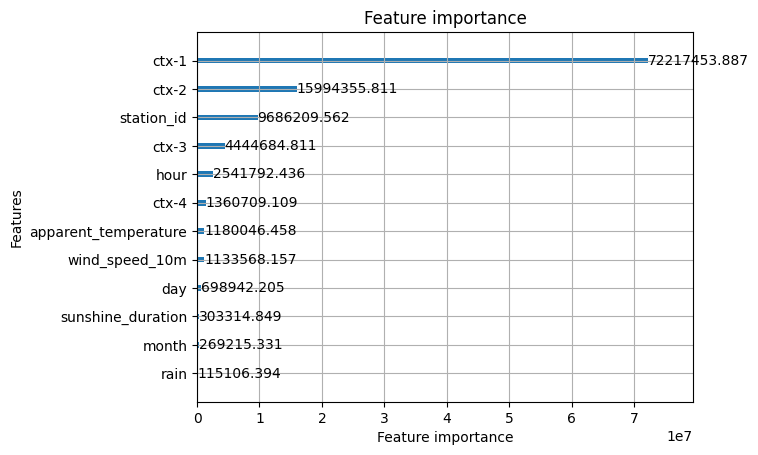

In [24]:
# Train the model with the best parameters
model = lgb.LGBMRegressor(**best_params, n_jobs=-1)
model.fit(X_train, logit(y_train.clip(1e-6, 1-1e-6)))

# Predict the test set
y_pred = model.predict(X_test)

# Calculate the RMSE
rmse = mean_squared_error(y_test, expit(y_pred)) ** 0.5
print('RMSE:', rmse)

# Plot the feature importance
plt.figure(figsize=(10, 6))
lgb.plot_importance(model, importance_type='gain')
plt.show()

Kaggle submission

In [ ]:
# Load submission metadata
submission_metadata = pd.read_csv('metadata_sample_submission_2025.csv')

# Data type conversion
submission_metadata['station_id'] = submission_metadata['station_id'].astype('category')
submission_metadata['hour'] = submission_metadata['hour'].astype('int32')
submission_metadata['day'] = submission_metadata['day'].astype('int32')
submission_metadata['month'] = submission_metadata['month'].astype('int32')

# Convert ctx-* columns to float32
for ctx_col in ['ctx-1', 'ctx-2', 'ctx-3', 'ctx-4']:
    submission_metadata[ctx_col] = submission_metadata[ctx_col].astype('float32')

# print(submission_metadata.head())

# Get weather data

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 41.3888,
	"longitude": 2.159,
	"start_date": "2024-06-01",
	"end_date": "2024-12-31",
	"hourly": ["rain", "apparent_temperature", "wind_speed_10m", "sunshine_duration"],
	"timezone": "Europe/Berlin"
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation {response.Elevation()} m asl")
print(f"Timezone {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0 {response.UtcOffsetSeconds()} s")

							# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
# hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_rain = hourly.Variables(0).ValuesAsNumpy()
hourly_apparent_temperature = hourly.Variables(1).ValuesAsNumpy()
# hourly_relative_humidity_2m = hourly.Variables(3).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(2).ValuesAsNumpy()
# hourly_is_day = hourly.Variables(5).ValuesAsNumpy()
hourly_sunshine_duration = hourly.Variables(3).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
	end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

# hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["rain"] = hourly_rain
hourly_data["apparent_temperature"] = hourly_apparent_temperature
# hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
hourly_data["sunshine_duration"] = hourly_sunshine_duration

hourly_dataframe = pd.DataFrame(data = hourly_data)

# Set explicit month, day and hour columns
hourly_dataframe["month"] = hourly_dataframe["date"].dt.month
hourly_dataframe["day"] = hourly_dataframe["date"].dt.day
hourly_dataframe["hour"] = hourly_dataframe["date"].dt.hour

# Drop the date column
hourly_dataframe.drop(columns = ["date"], inplace = True)

# print(hourly_dataframe.head())

 # Merge the submission metadata with the weather data on month, day, and hour
submission_metadata = submission_metadata.merge(hourly_dataframe, on=['month', 'day', 'hour'], how='left')

new_submission = submission_metadata[FEATURES]

# Normalize the columns apparent_temperature, wind_speed_10m, sunshine_duration, and rain
new_submission['apparent_temperature'] = (new_submission['apparent_temperature'] - new_submission['apparent_temperature'].min()) / (new_submission['apparent_temperature'].max() - new_submission['apparent_temperature'].min())
new_submission['wind_speed_10m'] = (new_submission['wind_speed_10m'] - new_submission['wind_speed_10m'].min()) / (new_submission['wind_speed_10m'].max() - new_submission['wind_speed_10m'].min())
new_submission['sunshine_duration'] = (new_submission['sunshine_duration'] - new_submission['sunshine_duration'].min()) / (new_submission['sunshine_duration'].max() - new_submission['sunshine_duration'].min())
new_submission['rain'] = (new_submission['rain'] - new_submission['rain'].min()) / (new_submission['rain'].max() - new_submission['rain'].min())

# Conversion of the specific data to categories
new_submission['station_id'] = new_submission['station_id'].astype('category')
# new_submission['month'] = new_submission['month'].astype('category')
# new_submission['day'] = new_submission['day'].astype('category')
# new_submission['hour'] = new_submission['hour'].astype('category')

# Predict the new data
y_pred = model.predict(new_submission)

# Apply the expit transformation
y_pred = expit(y_pred)

y_pred

Coordinates 41.37082290649414°N 2.068965435028076°E
Elevation 44.0 m asl
Timezone b'Europe/Berlin'b'GMT+1'
Timezone difference to GMT+0 3600 s
[LightGBM] [Warning] min_data_in_leaf is set=43, min_child_samples=28 will be ignored. Current value: min_data_in_leaf=43
[LightGBM] [Warning] feature_fraction is set=0.809322104218593, colsample_bytree=0.7902825766691579 will be ignored. Current value: feature_fraction=0.809322104218593
[LightGBM] [Warning] lambda_l2 is set=0.0004090306178504477, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0004090306178504477
[LightGBM] [Warning] lambda_l1 is set=0.0013742859179868747, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0013742859179868747
[LightGBM] [Warning] bagging_fraction is set=0.6514422058425843, subsample=0.7001234838005687 will be ignored. Current value: bagging_fraction=0.6514422058425843
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5


/tmp/ipykernel_133275/884322583.py:85: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_submission['apparent_temperature'] = (new_submission['apparent_temperature'] - new_submission['apparent_temperature'].min()) / (new_submission['apparent_temperature'].max() - new_submission['apparent_temperature'].min())
/tmp/ipykernel_133275/884322583.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_submission['wind_speed_10m'] = (new_submission['wind_speed_10m'] - new_submission['wind_speed_10m'].min()) / (new

array([0.32043676, 0.47160044, 0.73411408, ..., 0.4865273 , 0.5073448 ,
       0.5203157 ], shape=(401511,))

In [21]:
# Convert the predictions to a pandas dataframe
submission = pd.DataFrame(y_pred, columns=['docks_available'])
# Change the column name from docks_available to percentage_docks_available
submission.rename(columns={'docks_available': 'percentage_docks_available'}, inplace=True)
# Save as submission.csv with the first column name index
submission.to_csv('submission.csv', index_label='index')
submission

,percentage_docks_available
0,0.320437
1,0.471600
2,0.734114
3,0.796749
4,0.781680
...,...
401506,0.898251
401507,0.421341
401508,0.486527
401509,0.507345


In [22]:
!kaggle competitions submit -c 2025-bike-availability-prediction -f submission.csv -m "Second try with normalized weather data and categorical date-time information"

100%|██████████████████████████████████████| 9.92M/9.92M [00:01<00:00, 7.57MB/s]
Successfully submitted to 2025 Bike Availability Prediction